# The Michelson Intererometer
The Michelson interferometer is one of the most fundamental optical configurations used in precision interferometry and forms the core of modern gravitational-wave detectors. It consists of a beam splitter that divides an incident laser beam into two perpendicular arms. After propagating through the two arms, the beams are reflected by highly reflective end mirrors and recombined at the beam splitter, where they interfere. The resulting interference pattern depends on the relative optical path lengths of the two arms.

<img src="simple_michelson_setup.png">

The four ports of the interferometer are commonly labelled North, East, South and West. Alternatively, the interferometer arms are referred to as the $X$ and $Y$ arms, while the two output ports are known as the symmetric (bright) port and the anti-symmetric (dark) port. In gravitational-wave detectors, the anti-symmetric port serves as the primary output because it is highly sensitive to differential changes in the arm lengths.

For an ideal Michelson interferometer with a 50:50 beam splitter and perfectly reflecting end mirrors, the electric field at the anti-symmetric (South) port is

$$
E_S
=
\frac{iE_0}{2}
\left(
e^{i2kL_N}
+
e^{i2kL_E}
\right),
$$

where $E_0$ is the incident field amplitude, $k=2\pi/\lambda$ is the wavenumber, and $L_N$ and $L_E$ denote the lengths of the North and East interferometer arms, respectively.

It is convenient to define the common and differential arm lengths as

$$
\bar{L}
=
\frac{L_N+L_E}{2},
\quad
\text{and}
\quad
\Delta L
=
L_N-L_E.
$$

Substituting
$2L_N = 2\bar{L}+\Delta L,
\ \text{and} \ 
2L_E = 2\bar{L}-\Delta L,$ into the expression for the output field gives
\begin{align}
E_S
&=
\frac{iE_0}{2}
e^{i2k\bar{L}}
\left(
e^{ik\Delta L}
+
e^{-ik\Delta L}
\right) =
iE_0
e^{i2k\bar{L}}
\cos(k\Delta L).
\end{align}

Since a photodetector measures optical power rather than electric field, the detected signal is

$$
P
=
E_SE_S^{*}
=
P_0
\cos^2(k\Delta L)
\implies
P
=
P_0
\cos^2
\left(
\frac{2\pi\Delta L}{\lambda}
\right),
$$

where $P_0$ is the input laser power.

The output power varies periodically with the differential arm length, exhibiting maxima when the returning beams interfere constructively and minima when they interfere destructively. The operating point at which the output power becomes zero is known as the \textit{dark fringe}. Modern gravitational-wave detectors are operated at, or very close to, this dark-fringe condition. In this configuration, almost all of the carrier light is reflected back towards the laser, while tiny differential changes in the arm lengths, such as those produced by passing gravitational waves, generate measurable signals at the anti-symmetric port.

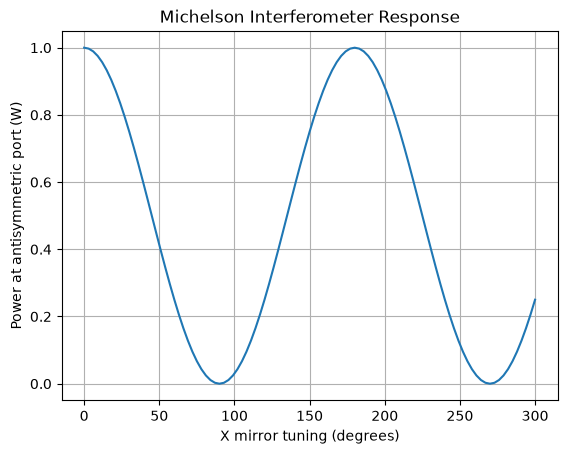

In [2]:
import finesse
from finesse.analysis.actions import Xaxis

model = finesse.Model()
model.parse("""
l L0 P=1                     # 1 W input laser

s sin L0.p1 BS.p1 L=0        # laser -> beamsplitter
bs BS R=0.5 T=0.5 alpha=45   # 50:50 beamsplitter

s sx BS.p3 MX.p1 L=1         # X arm, 1 m long
m MX R=1 T=0                 # X end mirror (perfect reflector)

s sy BS.p2 MY.p1 L=1         # Y arm, 1 m long
m MY R=1 T=0                 # Y end mirror

pd AS BS.p4.o          # power at the dark (antisymmetric) port

xaxis(MX.phi, lin, 0, 300, 100)   # scan the X mirror tuning around the fringe
""")

out = model.run(
    Xaxis(
        parameter='MX.phi',
        mode='lin',
        start=0,
        stop=300,
        steps=100
    )
)

# Plot the results
import matplotlib.pyplot as plt
plt.plot(out.x[0], out['AS'])
plt.xlabel('X mirror tuning (degrees)')
plt.ylabel('Power at antisymmetric port (W)')
plt.title('Michelson Interferometer Response')
plt.grid()
plt.show()